In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
import src.utils as utils
from src.visualization import Visualization
import copy
from src.risk_computations import RiskComputations, diff_to_exponents, diff_sgd_vs_approx
from src.utils import save_risk_results
from src.asymptotics import ZTransform_constant


In [2]:
from src import asymptotics


T=1000
sigma = 0.1
dim = 100

eta = 0.1
eta_range = np.logspace(-4, 2, 30)
t_values = np.linspace(0, T-1, 10, dtype=int)

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)
constant = ConstantSchedule(steps=T, base_lr=eta)

beta = 0
x0 = np.array([1/i**beta for i in range(1, dim+1)])


schedules1 = [constant]
asymptotics_analysis = ZTransform_constant(model, x0)

(100,) (100, 100)


c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in multiply
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in add
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:94: RuntimeWarning: overflow encountered in add
  m_t = diag_part * m_t + (lr**2) * lambda_vec * dot_m
c:\Users\ordinateur\Documents\GitHub\Least_Squares\src\SGD.py:95: RuntimeWarning: overflow encountered in multiply
  v_t = diag_part * v_t + (lr**2) * lambda_vec * dot_v + (lr**2 * irreducible_noise) * lambda_vec


Optimization results saved to saved_files\base_lr\optimize_results_True SGD_t_value_final_2026-04-20_17-56-10.json


In [ ]:
approx, ztransform = asymptotics_analysis.compute_all_approx_vs_z_transform()
approx = {"constant": approx}
ztransform = {"constant": ztransform}

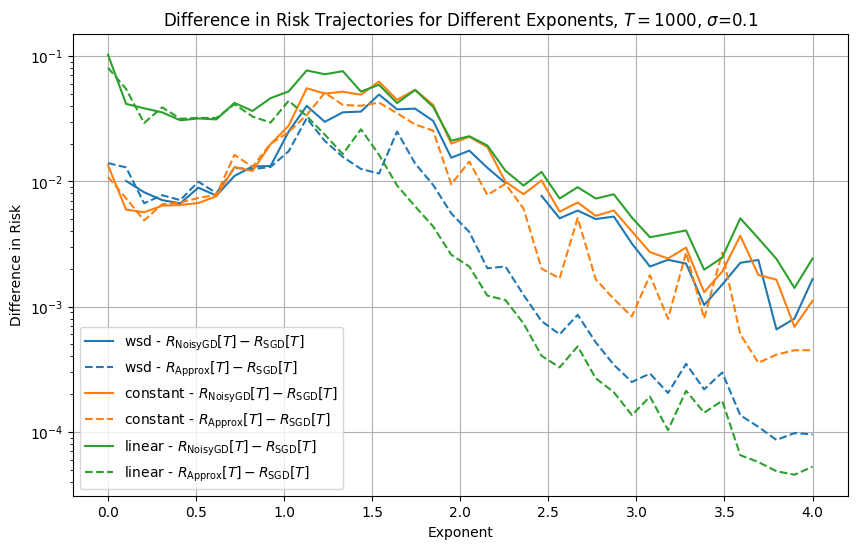

In [ ]:
visu = Visualization(schedules=schedules1 ,schedules_name=["constant"])
visu.plot_sgd_classes_comparison(
    risks_class1=approx, 
    risks_class2=ztransform,
    title=rf"Approximate vs Z-transform risks for {model.__class__.__name__} with {constant.__class__.__name__}", 
    ylabel="Difference in Risk",
    logscale=True,
    label_class1=r"$R_\text{Approx}[T]$",
    label_class2=r"$R_\text{ZTransform}[T]$",
    savefig=True)

In [ ]:
from src.utils import save_risk_results

save_risk_results(diff_results, "diff_sgd_noisy_gd_exponents")
save_risk_results(diff_approx_vs_sgd, "diff_sgd_approx_exponents")

Risk results saved to saved_files\risks\diff_sgd_noisy_gd_exponents
Risk results saved to saved_files\risks\diff_sgd_approx_exponents


'saved_files\\risks\\diff_sgd_approx_exponents'